<a href="https://colab.research.google.com/github/Dxrksvng/eng-score-exit/blob/main/image_alignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
# Imports
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read reference image
refFilename = "form.jpg"
iml = cv2.cvtColor (iml, cv2.COLOR_BGR2RGB)
# Read image to be aligned
imPilename = "scanned-form. jpg"
print ("Reading image to align : ", imFilename)
im2 = cv2. imread (imPilename, Cv2. IMREAD_COLOR)
Imz = cvz.cvtColor(im2, cv2.COLOR_BGR2RGB)

# Display Images
plt. figure (figsize=[20,10]);
plt.subplot(121); plt.axis('off'); plt.imshow(iml); plt.title("Original Form" )
plt-subplot (122); plt.axis('off'); plt.imshow(im2): plt.title("Scanned Form" )

SyntaxError: illegal target for annotation (ipython-input-1-1488586668.py, line 18)

In [ ]:
#Convert images to grayscale
iml_gray = cv2. cvtColor (iml, cv2.COLOR_BGR2GRAY)
im2_gray = cv2.cvtColor (im2, cv2.COLOR_BGR2GRAY)

#Detect ORB features and compute descriptors.
MAX_NUM_FEATURES = 500
orb = cv2.ORB_create(MAX_NUM_FEATURES)
keypoints1, descriptors1 = orb.detectaAndCompute(iml_gray, None)
keypoints2, descriptors2 = orb.detectaAndCompute(im_gray, None)

#Display
iml_display = cv2.drawkeypoints(iml, keypointsl, outImagenp.array([]), color»(255, 0, 0), flags=cv2.DRAW_MATCHES_F
iml_display = cv2.drawKeypoints(im2, keypoints2, outImage-np.array([l), color=(255, 0, 0), flags=cv2. DRAW_MATCHES_F

plt.figure(figsize=[20,10])
plt.subplot (121); plt.axis('off'); plt. imshow(im1_display); plt. title("Original Form");
plt.subplot (122); plt.axis('off'): plt. imshow(im2_display); plt.title("Scanned Form" ):

In [ ]:
#Match features.
matcher = cv2. DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE _HAMMING)
matches = matcher match(descriptorsi, descriptors2, None)

#Sort matches by score
matches .sort(key=lambda x: x.distance, reverse=False)

#Remove not so good matches
numGoodMatches = int(len(matches) * 0.1)
matches = matches[:numGoodMatches]

#Draw top matches
im_matches = cv2.drawMatches(iml, keypointsl, im2, keypoints2, matches, None)
plt. figure(figsize"[40,10])
plt.imshow(im_matches): plt.axis('off'): plt.title("Original Form" );

In [ ]:
#Extract location of good matches
pointsl = np.zeros ( (len(matches), 2), dtype=np.float32)
points2 = np.zeros( (len(matches), 2), dtype=np.float32)
for i, match in enumerate (matches):
pointsi(i, :] = keypoints1[match.queryIdx] •pt
points2[i, :] = keypoints2(match.trainIdx]•pt
#Find homography
10 h, mask = cv2. findHomography(points2, pointsl, cv2. RANSAC)

# Use homography to warp image
height, width, channels - iml.shape
im2_reg = cv2.warpPerspective(im2, h, (width, height) )

#Display results
plt.figure(figsize»[20,10]):
plt.subplot (121); plt.imshow(iml); plt.axis('off'); plt.title("Original Form"):
plt.subplot (122); plt.imshow(im2_reg); plt.axis('off*); plt.title("Scanned Form");

In [5]:
import cv2
import os
import numpy as np

# --- 1. การตั้งค่า ---

# ⬇️⬇️⬇️ กรุณาแก้ไข Path ไปยังรูปภาพที่คุณต้องการหมุน ⬇️⬇️⬇️
INPUT_IMAGE_PATH = '/content/drive/MyDrive/lastest-ktep/conv-to-img/KMITL-TEP PILOT-1.png'

# ⬇️⬇️⬇️ กรุณาแก้ไข Path ไปยังโฟลเดอร์ที่คุณต้องการบันทึกผลลัพธ์ ⬇️⬇️⬇️
OUTPUT_FOLDER_PATH = "/content/drive/MyDrive/lastest-ktep/test-rotate"

# กำหนดองศาที่จะหมุนในแต่ละครั้ง
ANGLE_STEP = 30

# --- 2. เริ่มกระบวนการ ---

def rotate_image_in_steps(image_path, output_dir, step):
    """
    ฟังก์ชันสำหรับโหลดภาพและทำการหมุนทีละ step องศา จนถึง 360 องศา แล้วบันทึกไฟล์
    """
    # ตรวจสอบว่าไฟล์ Input มีอยู่จริงหรือไม่
    if not os.path.exists(image_path):
        print(f"Error: ไม่พบไฟล์ที่ '{image_path}'")
        return

    # โหลดรูปภาพ
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: ไม่สามารถอ่านไฟล์รูปภาพ '{image_path}' ได้")
        return

    # สร้างโฟลเดอร์สำหรับเก็บผลลัพธ์หากยังไม่มี
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"สร้างโฟลเดอร์สำหรับผลลัพธ์ที่: '{output_dir}'")

    # ดึงความสูง (h) และความกว้าง (w) ของภาพ
    (h, w) = image.shape[:2]
    # หาจุดศูนย์กลางของภาพ
    center = (w // 2, h // 2)

    # แยกชื่อไฟล์และนามสกุลออกจาก Path เดิม
    base_name, extension = os.path.splitext(os.path.basename(image_path))

    # วนลูปเพื่อสร้างภาพที่หมุนตามองศาที่กำหนด
    # range(start, stop, step)
    # *** ปรับค่า stop เป็น 361 เพื่อให้ลูปรวม 360 องศาเข้าไปด้วย ***
    for angle in range(step, 361, step):
        print(f"กำลังสร้างภาพที่หมุนไป {angle} องศา...")

        # คำนวณ Rotation Matrix
        M = cv2.getRotationMatrix2D(center, angle, 1.0)

        # ทำการหมุนภาพด้วยฟังก์ชัน warpAffine
        rotated_image = cv2.warpAffine(image, M, (w, h))

        # สร้างชื่อไฟล์ใหม่สำหรับภาพที่หมุนแล้ว
        output_filename = f"{base_name}_rotated_{angle}{extension}"
        output_path = os.path.join(output_dir, output_filename)

        # บันทึกไฟล์ภาพที่หมุนแล้ว
        cv2.imwrite(output_path, rotated_image)
        print(f"✅ บันทึกแล้วที่: {output_path}")

    print("\nกระบวนการหมุนรูปภาพเสร็จสมบูรณ์!")


# --- 3. เรียกใช้งานฟังก์ชันหลัก ---
if __name__ == '__main__':
    rotate_image_in_steps(INPUT_IMAGE_PATH, OUTPUT_FOLDER_PATH, ANGLE_STEP)

สร้างโฟลเดอร์สำหรับผลลัพธ์ที่: '/content/drive/MyDrive/lastest-ktep/test-rotate'
กำลังสร้างภาพที่หมุนไป 30 องศา...
✅ บันทึกแล้วที่: /content/drive/MyDrive/lastest-ktep/test-rotate/KMITL-TEP PILOT-1_rotated_30.png
กำลังสร้างภาพที่หมุนไป 60 องศา...
✅ บันทึกแล้วที่: /content/drive/MyDrive/lastest-ktep/test-rotate/KMITL-TEP PILOT-1_rotated_60.png
กำลังสร้างภาพที่หมุนไป 90 องศา...
✅ บันทึกแล้วที่: /content/drive/MyDrive/lastest-ktep/test-rotate/KMITL-TEP PILOT-1_rotated_90.png
กำลังสร้างภาพที่หมุนไป 120 องศา...
✅ บันทึกแล้วที่: /content/drive/MyDrive/lastest-ktep/test-rotate/KMITL-TEP PILOT-1_rotated_120.png
กำลังสร้างภาพที่หมุนไป 150 องศา...
✅ บันทึกแล้วที่: /content/drive/MyDrive/lastest-ktep/test-rotate/KMITL-TEP PILOT-1_rotated_150.png
กำลังสร้างภาพที่หมุนไป 180 องศา...
✅ บันทึกแล้วที่: /content/drive/MyDrive/lastest-ktep/test-rotate/KMITL-TEP PILOT-1_rotated_180.png
กำลังสร้างภาพที่หมุนไป 210 องศา...
✅ บันทึกแล้วที่: /content/drive/MyDrive/lastest-ktep/test-rotate/KMITL-TEP PILOT-1_rot

Reading reference image :  /content/drive/MyDrive/lastest-ktep/conv-to-img/KMITL-TEP PILOT-1.png
Reading image to align :  /content/drive/MyDrive/lastest-ktep/aug_transparent/KMITL-TEP PILOT-1.png_rotated_-30.png


/tmp/ipython-input-4-1619147805.py:117: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4-1619147805.py:117: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4-1619147805.py:117: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4-1619147805.py:117: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4-1619147805.py:117: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4-1619147805.py:117: UserWarning: Glyph 3616 (\N{THAI CHARACTER PHO SAMPHAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4-1619147805.py:117: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from fon

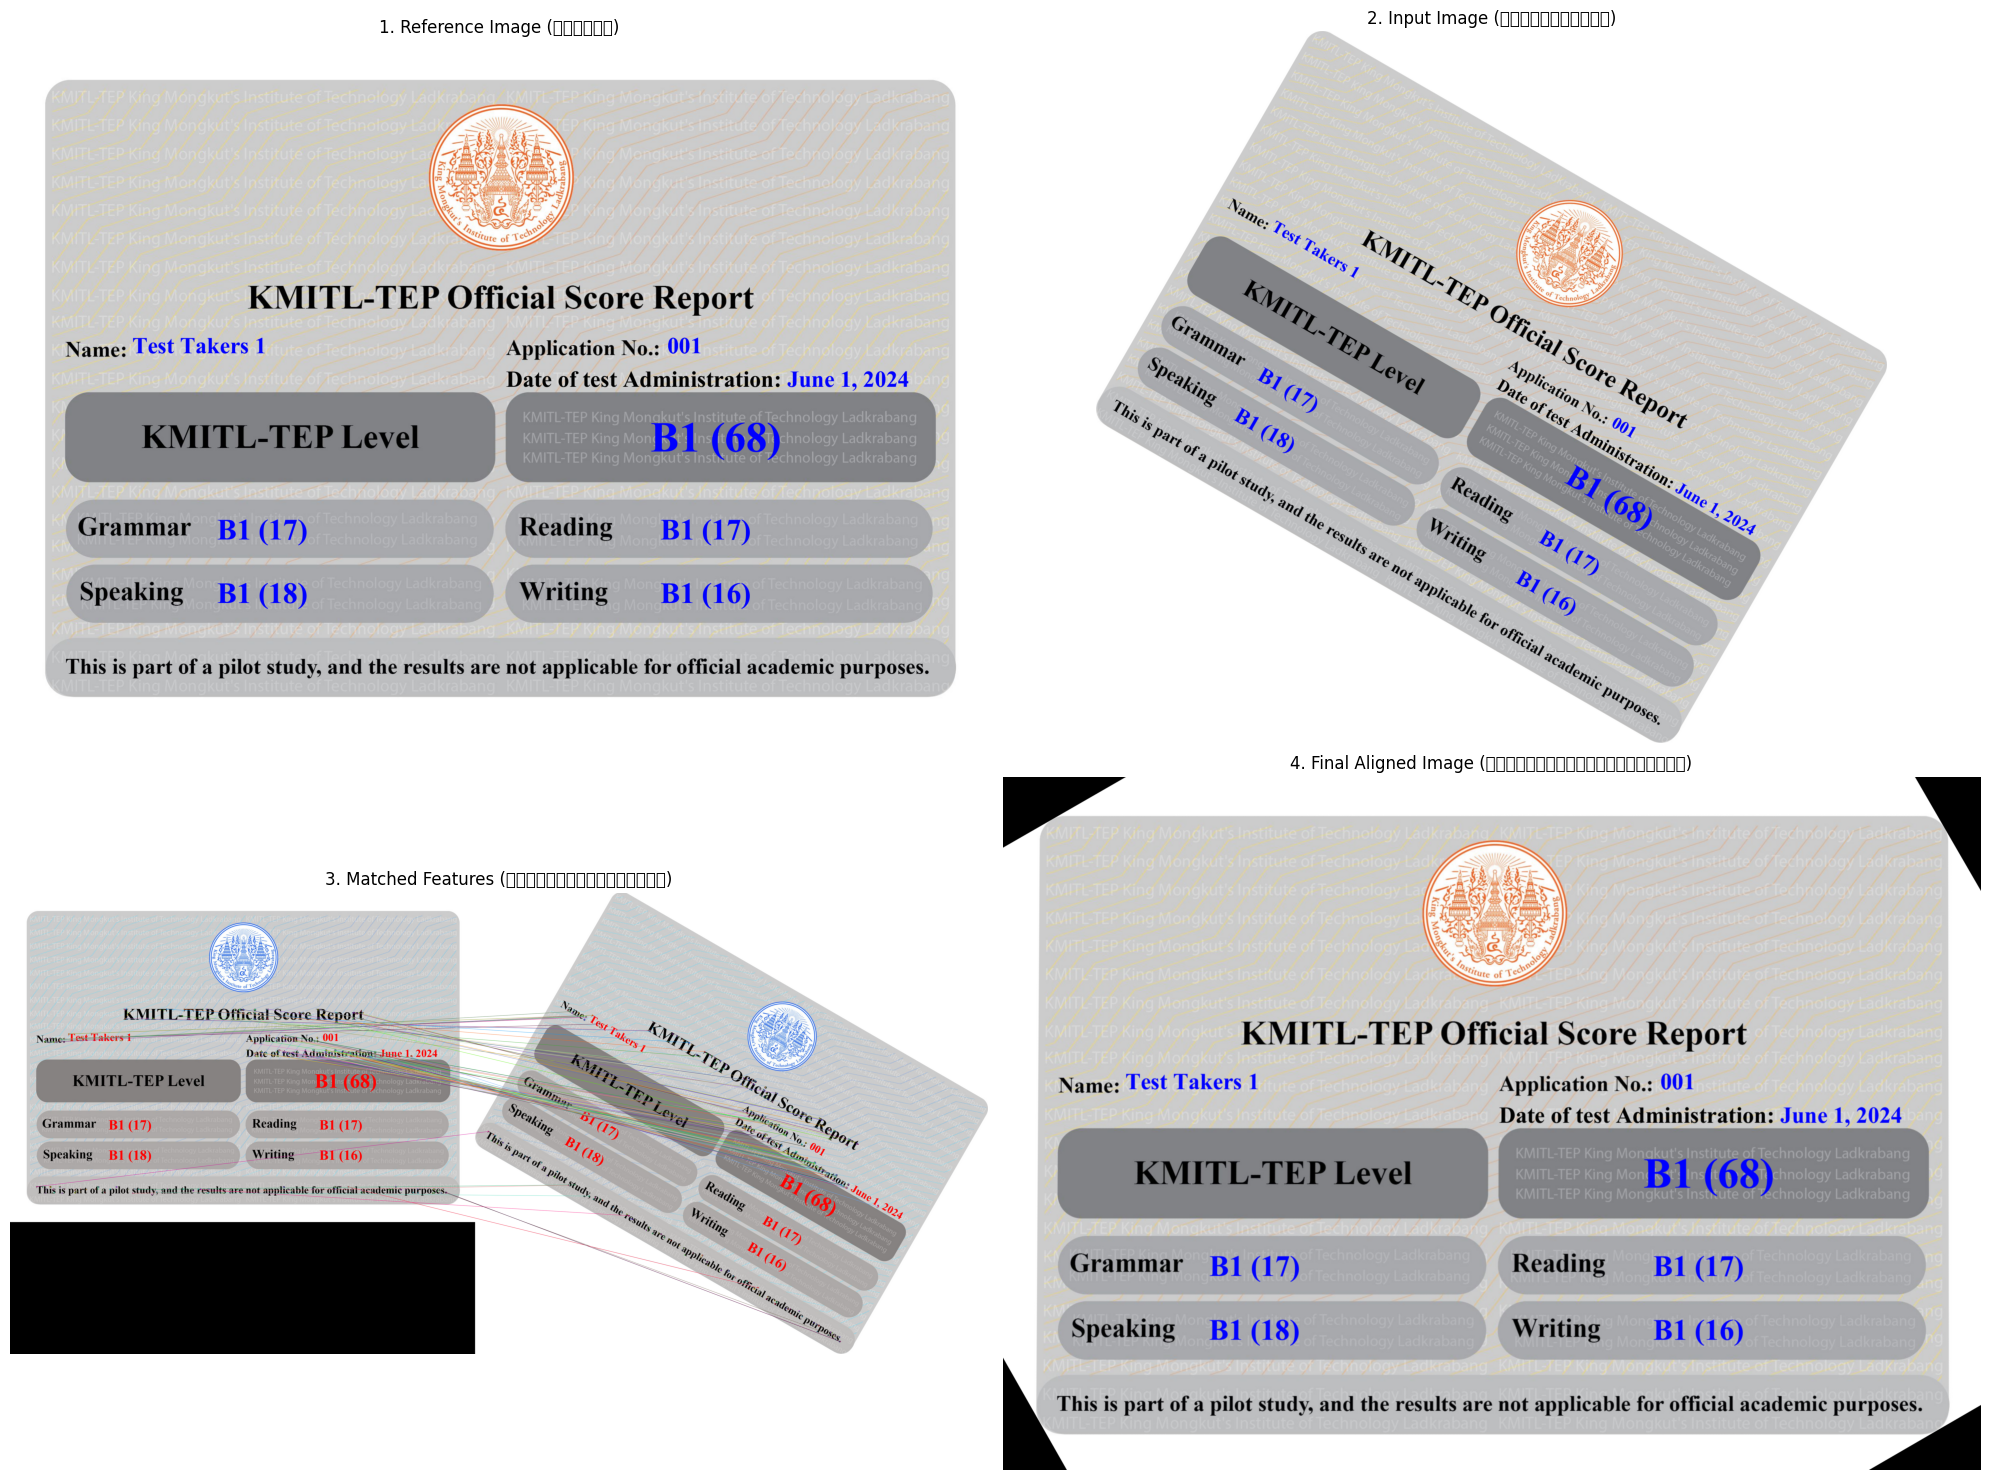

บันทึกภาพผลลัพธ์แล้วที่: aligned_output.jpg


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1. กำหนด PATH ของไฟล์รูปภาพ ---

# ⬇️⬇️⬇️ ภาพต้นแบบที่สมบูรณ์และตั้งตรง (ใช้ไฟล์ที่คุณส่งมา) ⬇️⬇️⬇️
REF_IMAGE_PATH = "/content/drive/MyDrive/lastest-ktep/conv-to-img/KMITL-TEP PILOT-1.png"

# ⬇️⬇️⬇️ ภาพถ่ายหรือภาพสแกนที่เอียง/เบี้ยว ที่เราต้องการทำให้ตรง ⬇️⬇️⬇️
# (กรุณาเปลี่ยนเป็น Path ของภาพถ่ายเอกสารใบเดียวกันที่ถ่ายมาเอียงๆ)
INPUT_IMAGE_PATH = "/content/drive/MyDrive/lastest-ktep/aug_transparent/KMITL-TEP PILOT-1.png_rotated_-30.png" # ตัวอย่าง: ใช้ภาพจากครั้งก่อน

# --- 2. โหลดภาพต้นแบบและภาพที่ต้องการจัดตำแหน่ง ---

print("Reading reference image : ", REF_IMAGE_PATH)
im1 = cv2.imread(REF_IMAGE_PATH, cv2.IMREAD_COLOR)
if im1 is None:
    raise FileNotFoundError(f"ไม่พบไฟล์ภาพต้นแบบที่: {REF_IMAGE_PATH}")
# แปลงสีสำหรับแสดงผลด้วย Matplotlib
im1_rgb = cv2.cvtColor(im1, cv2.COLOR_BGR2RGB)


print("Reading image to align : ", INPUT_IMAGE_PATH)
im2 = cv2.imread(INPUT_IMAGE_PATH, cv2.IMREAD_COLOR)
if im2 is None:
    raise FileNotFoundError(f"ไม่พบไฟล์ภาพ Input ที่: {INPUT_IMAGE_PATH}")
# แปลงสีสำหรับแสดงผลด้วย Matplotlib
im2_rgb = cv2.cvtColor(im2, cv2.COLOR_BGR2RGB)


# --- 3. แปลงภาพเป็น Grayscale เพื่อเตรียมหา Features ---

im1_gray = cv2.cvtColor(im1, cv2.COLOR_BGR2GRAY)
im2_gray = cv2.cvtColor(im2, cv2.COLOR_BGR2GRAY)


# --- 4. ตรวจจับ "จุดเด่น" ด้วย ORB Detector ---

# กำหนดจำนวน features สูงสุดที่ต้องการหา
MAX_FEATURES = 1000
orb = cv2.ORB_create(MAX_FEATURES)

# หา Keypoints และ Descriptors ของภาพทั้งสอง
keypoints1, descriptors1 = orb.detectAndCompute(im1_gray, None)
keypoints2, descriptors2 = orb.detectAndCompute(im2_gray, None)


# --- 5. จับคู่ "จุดเด่น" ที่ตรงกัน ---

# สร้าง Matcher แบบ Brute-Force
# ใช้ NORM_HAMMING เพราะเป็น metric ที่เหมาะสมสำหรับ ORB
matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# ทำการจับคู่
matches = matcher.match(descriptors1, descriptors2, None)

# เรียงลำดับผลลัพธ์การจับคู่ตามความ "เหมือน" (distance น้อย = เหมือนมาก)
matches = sorted(matches, key=lambda x: x.distance, reverse=False)

# คัดเลือกเฉพาะคู่ที่ดีที่สุด (เช่น 15% แรก) เพื่อกรองคู่ที่ผิดพลาดออก
numGoodMatches = int(len(matches) * 0.15)
matches = matches[:numGoodMatches]

# วาดเส้นเชื่อมโยงระหว่างคู่ที่ตรงกันเพื่อแสดงผล
im_matches = cv2.drawMatches(im1, keypoints1, im2, keypoints2, matches, None)


# --- 6. คำนวณ Homography และทำการดึงภาพ (Warping) ---

# ตรวจสอบว่ามีจำนวนคู่ที่ตรงกันมากพอหรือไม่
if len(matches) < 10:
    raise Exception("Not enough matches found to create a reliable homography.")

# ดึงตำแหน่ง (x,y) ของคู่ที่ตรงกันจากภาพทั้งสอง
points1 = np.zeros((len(matches), 2), dtype=np.float32)
points2 = np.zeros((len(matches), 2), dtype=np.float32)

for i, match in enumerate(matches):
    points1[i, :] = keypoints1[match.queryIdx].pt
    points2[i, :] = keypoints2[match.trainIdx].pt

# คำนวณหา Homography Matrix (h)
# ซึ่งคือ "สูตร" ในการแปลงภาพ im2 ให้ไปซ้อนทับ im1
h, mask = cv2.findHomography(points2, points1, cv2.RANSAC)

# ใช้ Homography Matrix (h) เพื่อดึงภาพ im2
height, width, channels = im1.shape
im2_registered = cv2.warpPerspective(im2, h, (width, height))
im2_registered_rgb = cv2.cvtColor(im2_registered, cv2.COLOR_BGR2RGB)


# --- 7. แสดงผลลัพธ์ทั้งหมด ---

plt.figure(figsize=(20, 15))

plt.subplot(2, 2, 1)
plt.imshow(im1_rgb)
plt.axis('off')
plt.title("1. Reference Image (ต้นแบบ)")

plt.subplot(2, 2, 2)
plt.imshow(im2_rgb)
plt.axis('off')
plt.title("2. Input Image (ภาพที่เอียง)")

plt.subplot(2, 2, 3)
plt.imshow(im_matches)
plt.axis('off')
plt.title("3. Matched Features (จุดเด่นที่ตรงกัน)")

plt.subplot(2, 2, 4)
plt.imshow(im2_registered_rgb)
plt.axis('off')
plt.title("4. Final Aligned Image (ภาพที่จัดตำแหน่งแล้ว)")

plt.tight_layout()
plt.show()

# บันทึกไฟล์ผลลัพธ์สุดท้าย (ถ้าต้องการ)
output_filename = "aligned_output.jpg"
cv2.imwrite(output_filename, im2_registered)
print(f"บันทึกภาพผลลัพธ์แล้วที่: {output_filename}")

In [ ]:
import cv2
import numpy as np
import os

def align_image_folder():
    """
    ฟังก์ชันสำหรับจัดตำแหน่งรูปภาพทั้งหมดในโฟลเดอร์
    เทียบกับภาพต้นแบบภาพเดียว
    """
    # --- 1. การตั้งค่า PATH และค่าพารามิเตอร์ ---

    # ⬇️⬇️⬇️ (สำคัญ) Path ไปยังภาพต้นแบบที่สมบูรณ์ 1 ภาพ (จะไม่เปลี่ยนแปลง) ⬇️⬇️⬇️
    REF_IMAGE_PATH = "/content/drive/MyDrive/lastest-ktep/conv-to-img/KMITL-TEP PILOT-1.png"

    # ⬇️⬇️⬇️ (สำคัญ) Path ไปยังโฟลเดอร์ที่เก็บภาพทั้งหมดที่ต้องการจัดตำแหน่ง ⬇️⬇️⬇️
    INPUT_FOLDER_PATH = "/content/drive/MyDrive/lastest-ktep/aug_transparent/"

    # ⬇️⬇️⬇️ (สำคัญ) Path ไปยังโฟลเดอร์ที่จะใช้บันทึกผลลัพธ์ทั้งหมด ⬇️⬇️⬇️
    OUTPUT_FOLDER_PATH = "/content/drive/MyDrive/lastest-ktep/aligned_output/"

    # กำหนดค่าพารามิเตอร์สำหรับ ORB และ Matcher
    MAX_FEATURES = 1000
    GOOD_MATCH_PERCENT = 0.15 # ใช้ 15% ของ match ที่ดีที่สุด

    # --- 2. เตรียมภาพต้นแบบ (ทำเพียงครั้งเดียว) ---

    # สร้างโฟลเดอร์สำหรับเก็บผลลัพธ์หากยังไม่มี
    if not os.path.exists(OUTPUT_FOLDER_PATH):
        os.makedirs(OUTPUT_FOLDER_PATH)
        print(f"สร้างโฟลเดอร์สำหรับผลลัพธ์ที่: '{OUTPUT_FOLDER_PATH}'")

    print("กำลังประมวลผลภาพต้นแบบ (Reference Image)...")
    im_ref = cv2.imread(REF_IMAGE_PATH, cv2.IMREAD_COLOR)
    if im_ref is None:
        print(f"!!! Error: ไม่พบไฟล์ภาพต้นแบบที่: {REF_IMAGE_PATH}")
        return

    im_ref_gray = cv2.cvtColor(im_ref, cv2.COLOR_BGR2GRAY)

    # สร้าง ORB detector และ BFMatcher
    orb = cv2.ORB_create(MAX_FEATURES)
    matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

    # หา keypoints และ descriptors ของภาพต้นแบบล่วงหน้า
    keypoints_ref, descriptors_ref = orb.detectAndCompute(im_ref_gray, None)
    print("ประมวลผลภาพต้นแบบเสร็จสิ้น")
    print("-" * 30)

    # --- 3. วนลูปประมวลผลภาพในโฟลเดอร์ INPUT ---

    # กำหนดนามสกุลไฟล์ที่ต้องการ
    supported_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')

    for filename in os.listdir(INPUT_FOLDER_PATH):
        if filename.lower().endswith(supported_extensions):
            input_image_path = os.path.join(INPUT_FOLDER_PATH, filename)
            print(f"กำลังประมวลผล: {filename}")

            try:
                # โหลดภาพที่ต้องการจัดตำแหน่ง
                im_input = cv2.imread(input_image_path, cv2.IMREAD_COLOR)
                if im_input is None:
                    print(f"  -> ⚠️ ไม่สามารถอ่านไฟล์ได้ ข้าม...")
                    continue

                im_input_gray = cv2.cvtColor(im_input, cv2.COLOR_BGR2GRAY)

                # หา keypoints และ descriptors ของภาพ input
                keypoints_input, descriptors_input = orb.detectAndCompute(im_input_gray, None)

                if descriptors_input is None:
                    print(f"  -> ⚠️ ไม่พบ features ในภาพนี้ ข้าม...")
                    continue

                # จับคู่ features กับภาพต้นแบบ
                matches = matcher.match(descriptors_ref, descriptors_input, None)
                matches = sorted(matches, key=lambda x: x.distance, reverse=False)
                numGoodMatches = int(len(matches) * GOOD_MATCH_PERCENT)
                matches = matches[:numGoodMatches]

                # ตรวจสอบว่ามีจำนวน match เพียงพอหรือไม่
                if len(matches) < 10:
                    print(f"  -> ⚠️ พบจุดที่ตรงกันน้อยเกินไป ไม่สามารถจัดตำแหน่งได้ ข้าม...")
                    continue

                # ดึงตำแหน่งของ good matches
                points_ref = np.zeros((len(matches), 2), dtype=np.float32)
                points_input = np.zeros((len(matches), 2), dtype=np.float32)

                for i, match in enumerate(matches):
                    points_ref[i, :] = keypoints_ref[match.queryIdx].pt
                    points_input[i, :] = keypoints_input[match.trainIdx].pt

                # คำนวณ Homography และทำการ Warp
                h, mask = cv2.findHomography(points_input, points_ref, cv2.RANSAC)
                height, width, channels = im_ref.shape
                im_registered = cv2.warpPerspective(im_input, h, (width, height))

                # บันทึกไฟล์ผลลัพธ์
                output_filename = f"aligned_{filename}"
                output_path = os.path.join(OUTPUT_FOLDER_PATH, output_filename)
                cv2.imwrite(output_path, im_registered)
                print(f"  -> ✅ จัดตำแหน่งสำเร็จ! บันทึกแล้วที่: {output_filename}")

            except Exception as e:
                print(f"  -> ❌ เกิดข้อผิดพลาดระหว่างประมวลผลไฟล์ {filename}: {e}")

    print("-" * 30)
    print("การประมวลผลทั้งโฟลเดอร์เสร็จสมบูรณ์!")

# --- 4. เรียกใช้งานฟังก์ชัน ---
if __name__ == '__main__':
    align_image_folder()